HOUSE PRICE PREDICTION

In [ ]:
#Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

=== DATASET SHAPE ===
(2000, 10)

=== FIRST 5 ROWS ===


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



=== DATA INFO & TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB

=== SUMMARY STATISTICS (NUMERICAL) ===


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000



=== CATEGORICAL FEATURE VALUE COUNTS ===

--- Location ---


...


--- Condition ---


,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461



--- Garage ---


,count
Garage,
No,1038
Yes,962



=== DATA INTEGRITY CHECK ===
Total Missing Values: 0
Total Duplicate Rows: 0


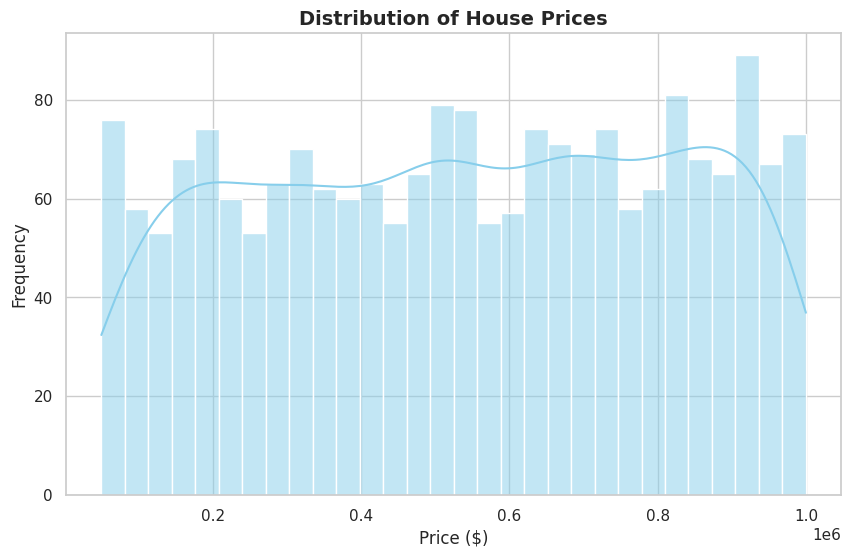

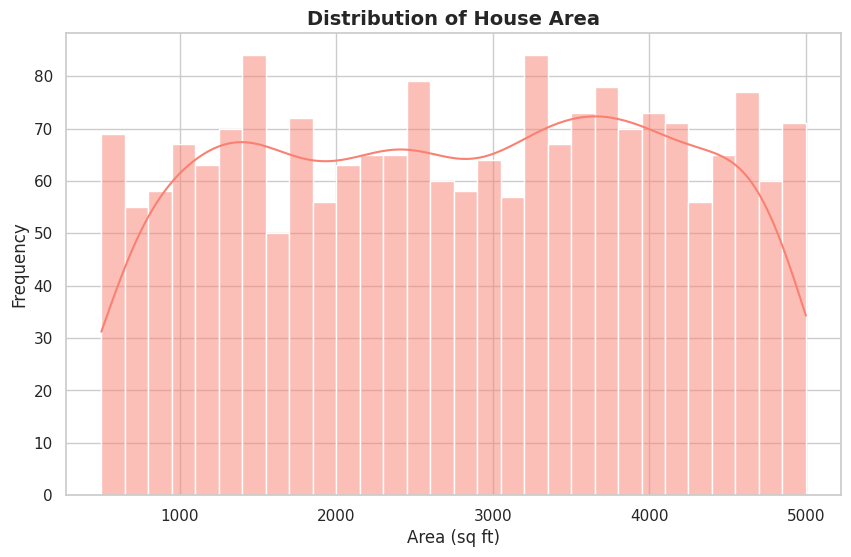

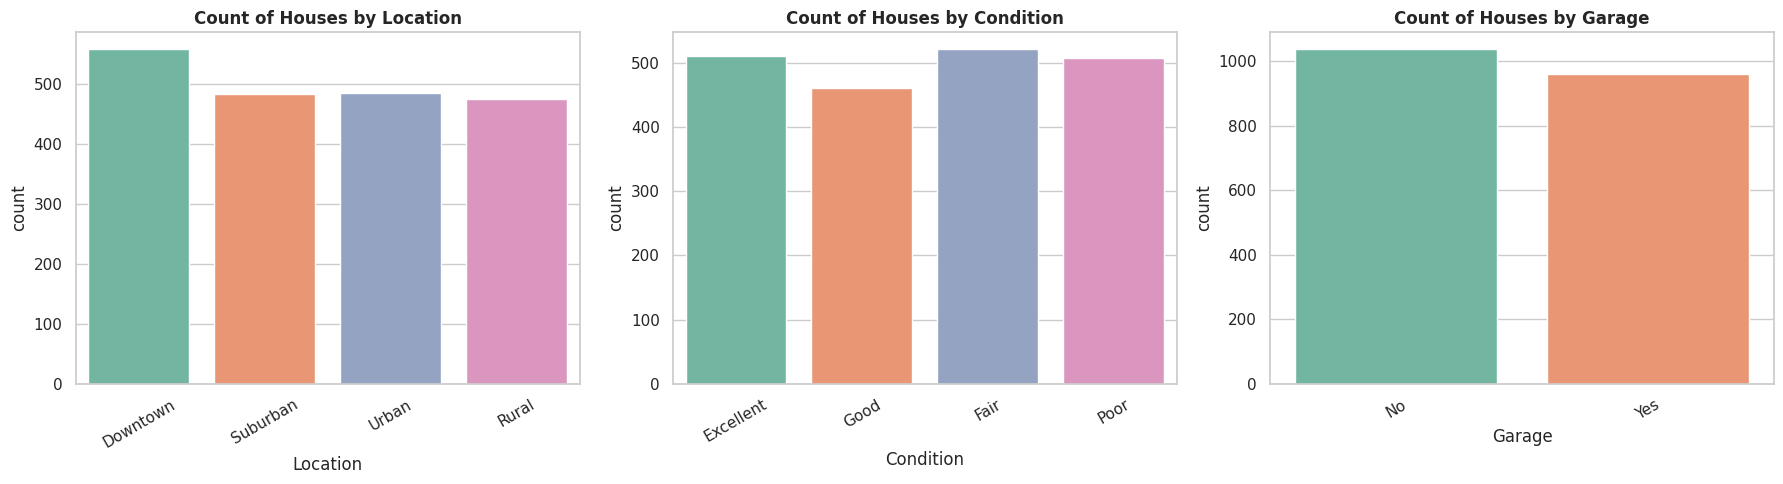

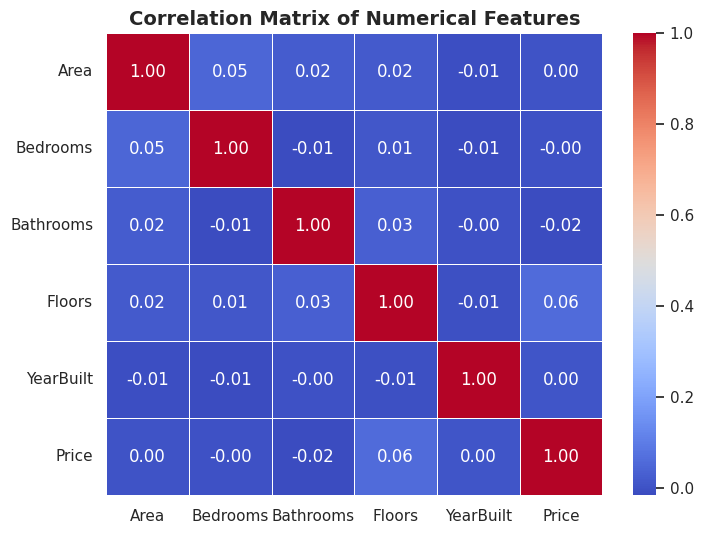

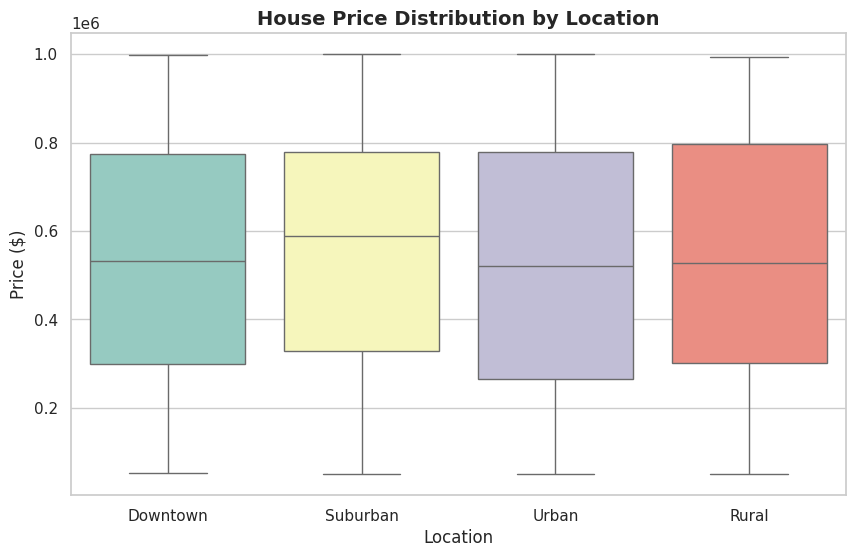

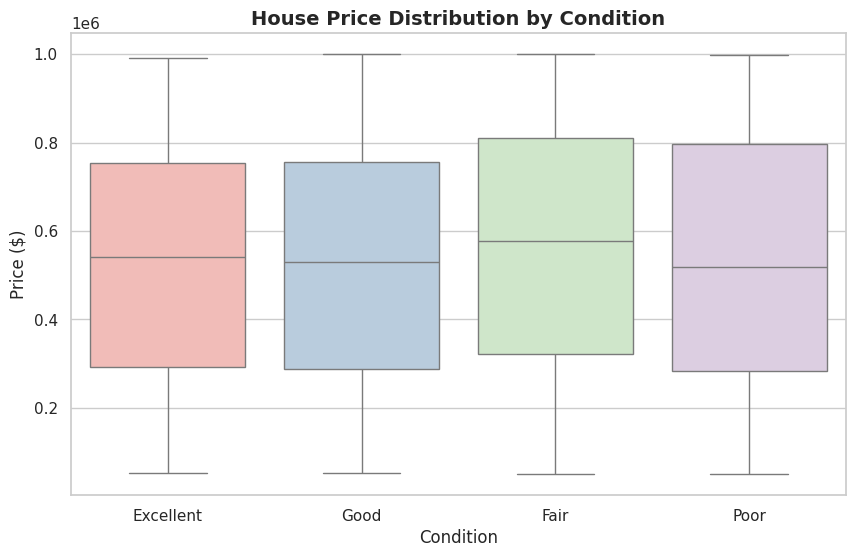

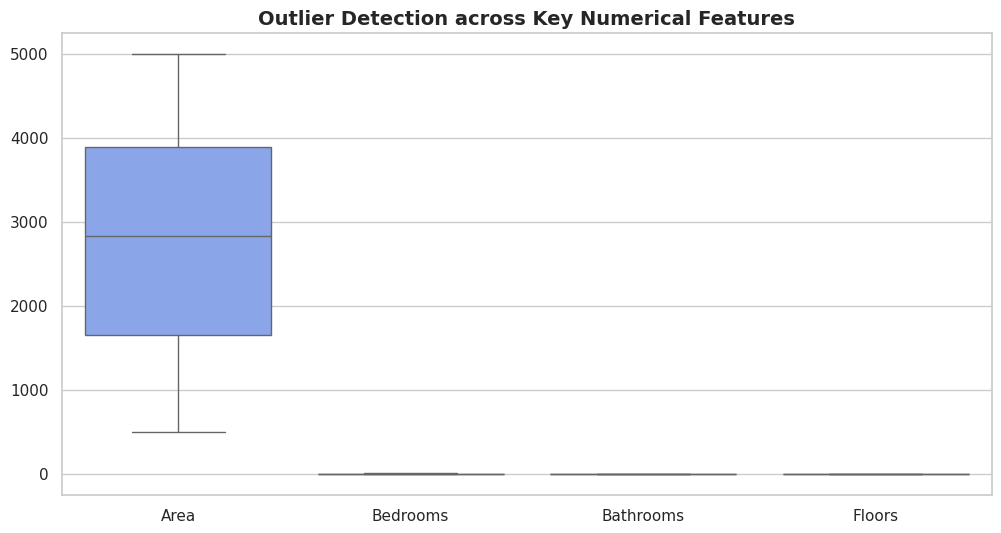

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style for plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the dataset
df = pd.read_csv('House_Price_Prediction_Dataset_a2sttc.csv')

# 2. Data Understanding / Inspection
print('=== DATASET SHAPE ===')
print(df.shape)

print('\n=== FIRST 5 ROWS ===')
display(df.head())

print('\n=== DATA INFO & TYPES ===')
df.info()

print('\n=== SUMMARY STATISTICS (NUMERICAL) ===')
display(df.describe())

# Categorical summary
categorical_cols = df.select_dtypes(include=['object']).columns
print('\n=== CATEGORICAL FEATURE VALUE COUNTS ===')
for col in categorical_cols:
  print(f'\n--- {col} ---')
  display(df[col].value_counts())

# 3. Data Cleaning Check (Missing Values & Duplicates)
print('\n=== DATA INTEGRITY CHECK ===')
print(f'Total Missing Values: {df.isnull().sum().sum()}')
print(f'Total Duplicate Rows: {df.duplicated().sum()}')

# 4. Univariate Analysis (Visualizations)
# Distribution of House Prices
plt.figure()
sns.histplot(df['Price'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Distribution of House Area
plt.figure()
sns.histplot(df['Area'], kde=True, color='salmon', bins=30)
plt.title('Distribution of House Area', fontsize=14, fontweight='bold')
plt.xlabel('Area (sq ft)')
plt.ylabel('Frequency')
plt.show()

# Count plots for categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
  sns.countplot(
      data=df,
      x=col,
      ax=axes[i],
      palette='Set2',
      hue=col,
      legend=False,
  )
  axes[i].set_title(f'Count of Houses by {col}', fontsize=12, fontweight='bold')
  axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# 5. Bivariate & Multivariate Analysis
# Correlation Heatmap (Numerical columns excluding ID)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Id'])
correlation_matrix = numeric_df.corr()
sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title(
    'Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold'
)
plt.show()

# Price vs Location Boxplot
plt.figure()
sns.boxplot(data=df, x='Location', y='Price', palette='Set3', hue='Location')
plt.title('House Price Distribution by Location', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Price ($)')
plt.show()

# Price vs Property Condition Boxplot
plt.figure()
sns.boxplot(data=df, x='Condition', y='Price', palette='Pastel1', hue='Condition')
plt.title('House Price Distribution by Condition', fontsize=14, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Price ($)')
plt.show()

# 6. Outlier Detection via Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[['Area', 'Bedrooms', 'Bathrooms', 'Floors']], palette='coolwarm'
)
plt.title(
    'Outlier Detection across Key Numerical Features',
    fontsize=14,
    fontweight='bold',
)
plt.show()

In [1]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-3.5-flash',), value='google/ge…